# 06 — CD4 subset markers and high vs low IRC comparisons in CD4 Teff
Input: clean CD4 object (05): Naive/CM, Teff, Treg (23,381 cells).
Part 1: subset-defining genes (Fig 5b). Part 2: high vs low IRC in Teff (Fig 5d–k, Ext Data 7c–h).

## Step 12.1 — Setup and load the clean CD4 object

In [1]:
suppressPackageStartupMessages({
  library(Seurat); library(tidyverse); library(patchwork)
})
proj <- "/mnt/d/project3_IFN-I"
set.seed(42)
options(future.globals.maxSize = Inf)

cd4 <- readRDS(file.path(proj, "results/objects/05_cd4_clean.rds"))
Idents(cd4) <- "cd4_subset"
table(Idents(cd4))
requireNamespace("presto", quietly = TRUE)   # should print TRUE


Naive/CM     Teff     Treg 
   13984     7444     1953 

## Step 12.2 — Genes defining each CD4 subset (Fig 5b)

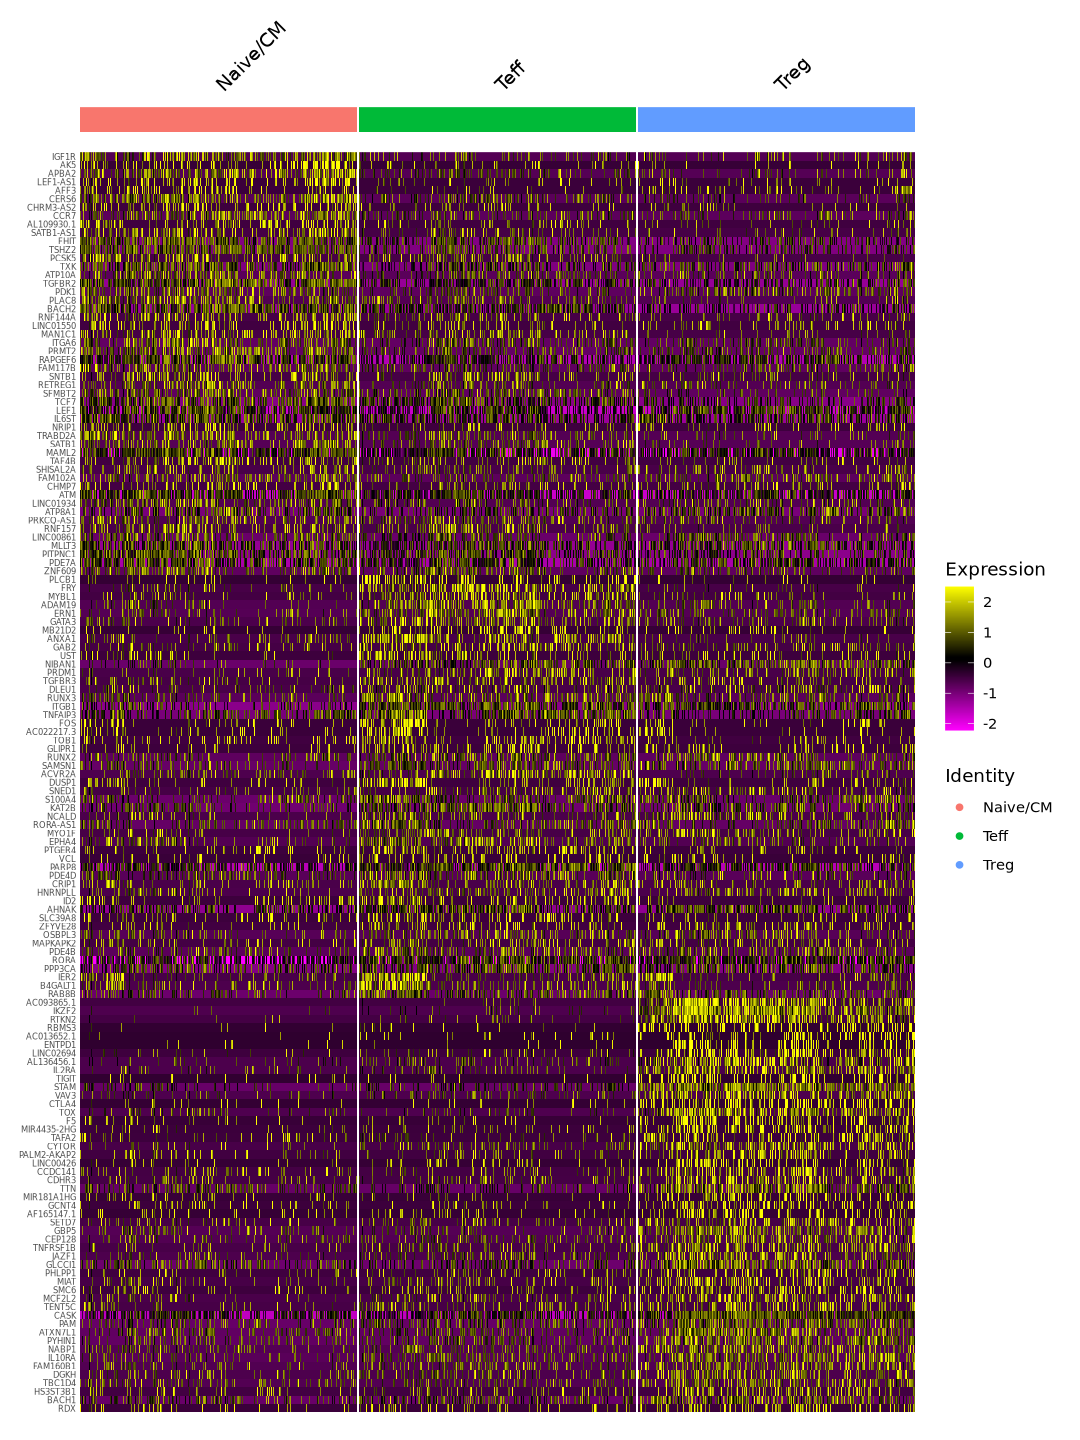

In [2]:
subset_markers <- FindAllMarkers(cd4, only.pos = TRUE, min.pct = 0.25,
                                 logfc.threshold = 0.25, verbose = FALSE)
write_csv(subset_markers, file.path(proj, "results/tables/06_cd4_subset_markers.csv"))

top50 <- subset_markers |>
  filter(p_val_adj < 0.05) |>
  group_by(cluster) |>
  slice_max(avg_log2FC, n = 50) |>
  ungroup()

cd4_ds <- subset(cd4, downsample = 500)
cd4_ds <- ScaleData(cd4_ds, features = unique(top50$gene), verbose = FALSE)

options(repr.plot.width = 9, repr.plot.height = 12)
hm <- DoHeatmap(cd4_ds, features = unique(top50$gene), raster = TRUE, size = 4) +
  theme(axis.text.y = element_text(size = 5))
hm
ggsave(file.path(proj, "figures/trackB/06_fig5b_cd4_subset_heatmap.png"),
       hm, width = 9, height = 12, dpi = 150)
rm(cd4_ds); invisible(gc())

## Step 12.3 — Compare with the genes named in the paper's Fig 5b

In [3]:
paper_genes <- tibble(
  paper_subset = rep(c("Naive/CM", "Teff", "TEMRA", "Treg"), times = c(7, 7, 7, 8)),
  gene = c("TSHZ2", "CCR7", "TGFBR2", "BACH2", "LEF1", "TCF7", "AFF3",
           "GATA3", "RUNX2", "TGFBR3", "RORA", "RUNX3", "PRDM1", "CD226",
           "ZEB2", "CCL5", "VAV3", "CD74", "CBLB", "TGFB1", "ITGAL",
           "IKZF2", "TOX", "IL2RA", "ENTPD1", "BACH1", "CTLA4", "TIGIT", "IL10RA"))

fig5b_check <- paper_genes |>
  left_join(subset_markers |>
              filter(p_val_adj < 0.05) |>
              select(gene, our_subset = cluster, avg_log2FC),
            by = "gene") |>
  mutate(avg_log2FC = round(avg_log2FC, 2))
fig5b_check
write_csv(fig5b_check, file.path(proj, "results/tables/06_fig5b_paper_gene_check.csv"))

paper_subset,gene,our_subset,avg_log2FC
<chr>,<chr>,<fct>,<dbl>
Naive/CM,TSHZ2,Naive/CM,1.26
Naive/CM,CCR7,Naive/CM,1.40
Naive/CM,TGFBR2,Naive/CM,1.21
Naive/CM,BACH2,Naive/CM,1.06
Naive/CM,LEF1,Naive/CM,0.86
Naive/CM,TCF7,Naive/CM,0.86
Naive/CM,AFF3,Naive/CM,1.73
Teff,GATA3,Teff,1.66
Teff,RUNX2,Teff,1.01


### Fig 5b reproduction
- Subset markers (presto Wilcoxon) vs genes labelled in paper Fig 5b:
  Naive/CM 7/7, Teff 7/7, Treg 8/8 match (22/22). CD226 significant but below top-50 (log2FC 0.54).
- PRDM1 also enriched in Treg (Blimp-1 in effector Tregs); IL10RA in Treg and weakly Teff.
- TEMRA genes CCL5, ZEB2, CBLB, ITGAL not enriched in any subset -> TEMRA absent, not hidden in Teff.
- Method difference: paper used DESeq2 Wald test; we used Wilcoxon (presto) for subset markers.

## Part 2 — High vs low IRC in CD4 Teff (patients only)

## Step 12.4 — Extract Teff cells from patients

In [4]:
teff <- subset(cd4, subset = cd4_subset == "Teff" & group %in% c("high_IRC", "low_IRC"))
teff$group <- factor(teff$group, levels = c("high_IRC", "low_IRC"))
Idents(teff) <- "group"
teff
table(teff$sample, teff$group)

An object of class Seurat 
36601 features across 5690 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 2 layers present: data, counts
 7 dimensional reductions calculated: pca, umap.unintegrated, integrated.rpca, umap.rpca, pca_cd4, integrated_cd4, umap_cd4

    
     high_IRC low_IRC
  P1      587       0
  P2      937       0
  P3     1336       0
  P4      418       0
  P5        0     327
  P6        0     751
  P7        0     914
  P8        0     420

## Step 12.5 — The 6 IRC genes in high vs low IRC Teff (Ext Data Fig 7d)

gene,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MX1,0.00171,-0.2360,0.200,0.157,1
IFIT3,0.01230,-2.0500,0.025,0.036,1
ISG15,0.13200,0.0574,0.070,0.060,1
IRF7,0.24200,-0.1750,0.028,0.023,1
BST2,0.33600,-0.2250,0.123,0.128,1
EIF2AK2,0.74700,-0.2360,0.347,0.319,1


gene,high_mean,low_mean,p_patient
<chr>,<dbl>,<dbl>,<dbl>
BST2,0.143,0.151,1.000
EIF2AK2,0.530,0.544,1.000
IFIT3,0.033,0.113,0.886
IRF7,0.033,0.036,1.000
ISG15,0.089,0.087,0.886
MX1,0.281,0.285,1.000


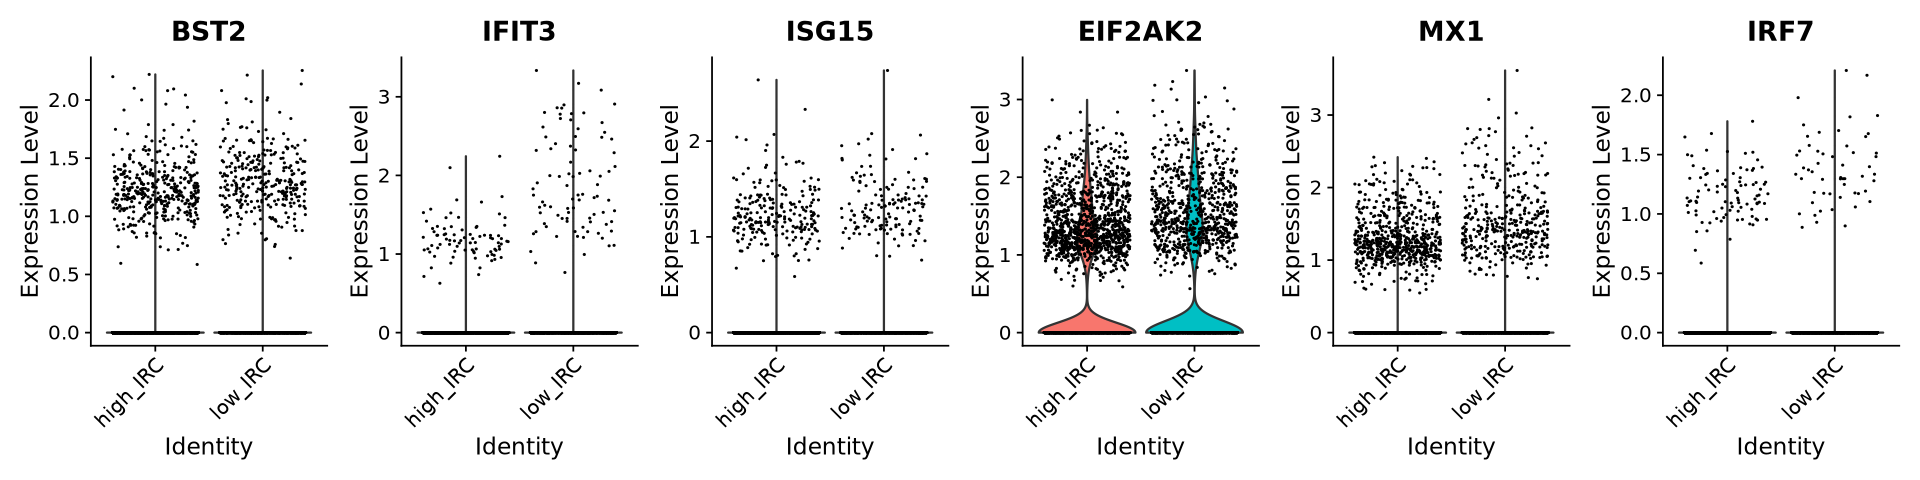

In [5]:
isg6 <- c("BST2", "IFIT3", "ISG15", "EIF2AK2", "MX1", "IRF7")

# Cell-level test (paper's approach)
isg_cell <- FindMarkers(teff, ident.1 = "high_IRC", ident.2 = "low_IRC", features = isg6,
                        logfc.threshold = 0, min.pct = 0, verbose = FALSE) |>
  rownames_to_column("gene") |>
  mutate(across(where(is.numeric), ~ signif(.x, 3)))
isg_cell

# Patient-level: mean expression and % expressing per patient
isg_patient <- FetchData(teff, vars = c(isg6, "sample", "group")) |>
  pivot_longer(all_of(isg6), names_to = "gene", values_to = "expr") |>
  group_by(gene, sample, group) |>
  summarise(mean_expr = mean(expr), pct_expr = 100 * mean(expr > 0), .groups = "drop")

isg_patient_test <- isg_patient |>
  group_by(gene) |>
  summarise(high_mean = round(mean(mean_expr[group == "high_IRC"]), 3),
            low_mean  = round(mean(mean_expr[group == "low_IRC"]), 3),
            p_patient = signif(wilcox.test(mean_expr ~ group, exact = TRUE)$p.value, 3),
            .groups = "drop")
isg_patient_test

write_csv(isg_cell, file.path(proj, "results/tables/06_isg6_teff_cell_level.csv"))
write_csv(isg_patient, file.path(proj, "results/tables/06_isg6_teff_per_patient.csv"))

options(repr.plot.width = 16, repr.plot.height = 4)
vp <- VlnPlot(teff, features = isg6, group.by = "group", pt.size = 0.05, ncol = 6)
vp
ggsave(file.path(proj, "figures/trackB/06_extfig7d_isg6_teff.png"), vp, width = 16, height = 4, dpi = 150)

### Ext Data Fig 7d — 6 IRC ISGs in Teff (high vs low IRC)
- Cell-level Wilcoxon: MX1 only clear hit (P = 0.0017; paper P = 7.3e-6); IFIT3 nominal P = 0.012
  (detected in 2.5–3.6% of cells); others P > 0.1. -> reproduces paper's pattern.
- Patient-level (4 vs 4 means): no differences (all P >= 0.89); MX1 means 0.281 vs 0.285.
  Cell-level MX1 "significance" not reflected between patients (pseudoreplication).
- Supports paper: no baseline ISG difference. Caveat: sparse genes (2–35% detection) limit power.

## Step 12.6 — Hallmark IFN-α response genes in Teff (Ext Data Fig 7c)

97 genes in set; 96 present in data



Higher in high IRC  Higher in low IRC      Not different 
                18                 15                 56 

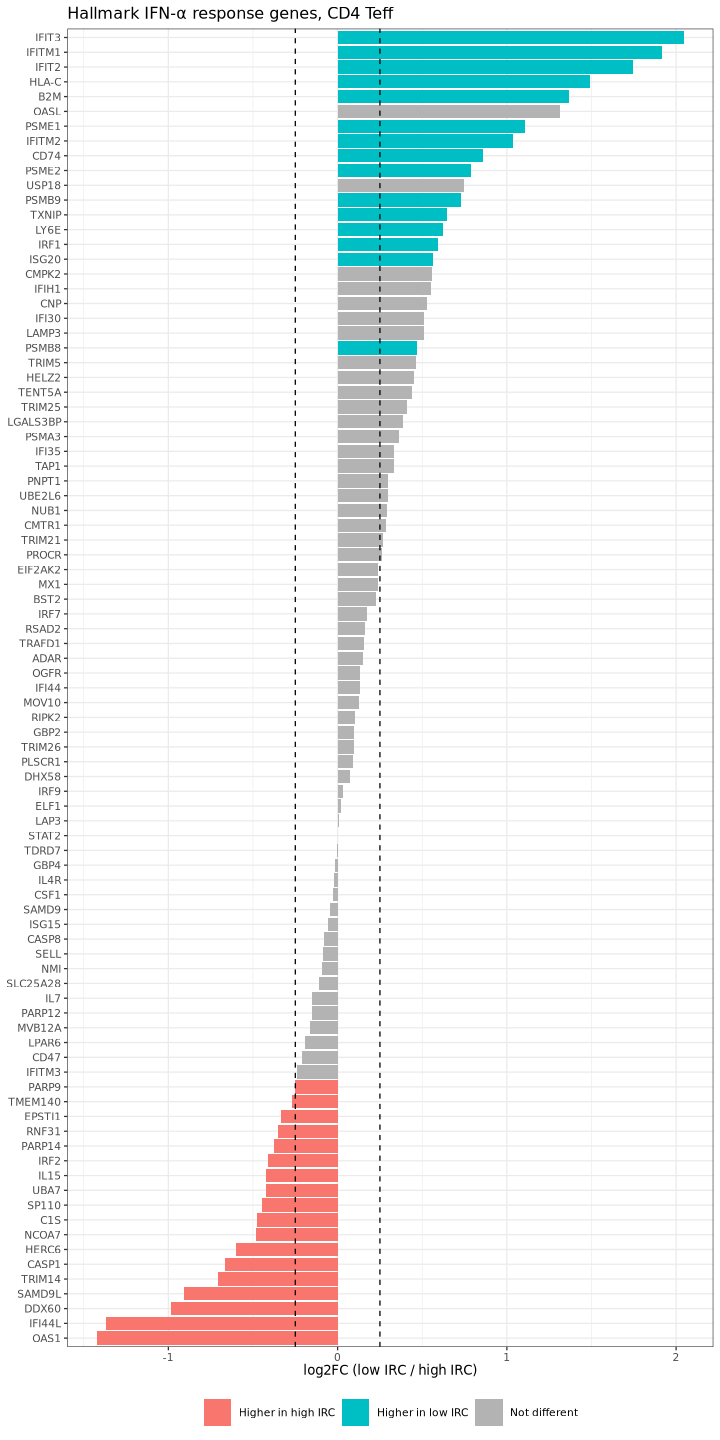

In [6]:
library(msigdbr)

ifna <- msigdbr(species = "Homo sapiens", collection = "H") |>
  filter(gs_name == "HALLMARK_INTERFERON_ALPHA_RESPONSE") |>
  pull(gene_symbol) |> unique()
ifna_det <- intersect(ifna, rownames(teff))
cat(length(ifna), "genes in set;", length(ifna_det), "present in data\n")

ifna_de <- FindMarkers(teff, ident.1 = "low_IRC", ident.2 = "high_IRC", features = ifna_det,
                       logfc.threshold = 0, min.pct = 0.01, verbose = FALSE) |>
  rownames_to_column("gene") |>
  mutate(p_adj_set = p.adjust(p_val, method = "BH"),
         direction = case_when(p_adj_set < 0.05 & avg_log2FC >  0.25 ~ "Higher in low IRC",
                               p_adj_set < 0.05 & avg_log2FC < -0.25 ~ "Higher in high IRC",
                               TRUE ~ "Not different")) |>
  arrange(desc(avg_log2FC))
table(ifna_de$direction)
write_csv(ifna_de, file.path(proj, "results/tables/06_extfig7c_hallmark_ifna_teff.csv"))

options(repr.plot.width = 6, repr.plot.height = 12)
p7c <- ggplot(ifna_de, aes(x = reorder(gene, avg_log2FC), y = avg_log2FC, fill = direction)) +
  geom_col() +
  coord_flip() +
  geom_hline(yintercept = c(-0.25, 0.25), linetype = "dashed") +
  scale_fill_manual(values = c("Higher in low IRC" = "#00BFC4",
                               "Higher in high IRC" = "#F8766D",
                               "Not different" = "grey70")) +
  labs(x = NULL, y = "log2FC (low IRC / high IRC)", fill = NULL,
       title = "Hallmark IFN-α response genes, CD4 Teff") +
  theme_bw(base_size = 8) + theme(legend.position = "bottom")
p7c
ggsave(file.path(proj, "figures/trackB/06_extfig7c_hallmark_ifna_teff.png"), p7c,
       width = 6, height = 12, dpi = 150)

## Step 12.7 — Compare with the genes named in Ext Data Fig 7c

In [7]:
paper_7c <- tibble(
  gene = c("B2M", "HLA-C", "TXNIP", "CD74", "NCOA7", "IFI44L", "EPSTI1", "SP110", "PARP14"),
  paper_direction = rep(c("Higher in low IRC", "Higher in high IRC"), times = c(4, 5)))

fig7c_check <- paper_7c |>
  left_join(ifna_de |> select(gene, avg_log2FC, p_adj_set, our_direction = direction), by = "gene") |>
  mutate(avg_log2FC = round(avg_log2FC, 2), p_adj_set = signif(p_adj_set, 3),
         agree = paper_direction == our_direction)
fig7c_check

gene,paper_direction,avg_log2FC,p_adj_set,our_direction,agree
<chr>,<chr>,<dbl>,<dbl>,<chr>,<lgl>
B2M,Higher in low IRC,1.37,0.00e+00,Higher in low IRC,TRUE
HLA-C,Higher in low IRC,1.49,0.00e+00,Higher in low IRC,TRUE
TXNIP,Higher in low IRC,0.65,1.17e-129,Higher in low IRC,TRUE
CD74,Higher in low IRC,0.86,4.76e-27,Higher in low IRC,TRUE
NCOA7,Higher in high IRC,-0.48,2.32e-31,Higher in high IRC,TRUE
IFI44L,Higher in high IRC,-1.37,5.16e-41,Higher in high IRC,TRUE
EPSTI1,Higher in high IRC,-0.33,3.76e-12,Higher in high IRC,TRUE
SP110,Higher in high IRC,-0.45,1.38e-20,Higher in high IRC,TRUE
PARP14,Higher in high IRC,-0.37,6.51e-15,Higher in high IRC,TRUE


### Ext Data Fig 7c — Hallmark IFN-alpha genes in Teff (low vs high IRC)
- 96/97 genes present; 89 tested (min.pct 0.01). Cell-level Wilcoxon, BH within set, |log2FC| > 0.25.
- 15 higher in low IRC, 18 higher in high IRC, 56 not different -> no one-directional IFN shift.
- Paper's 9 named genes: 9/9 agree (low: B2M, HLA-C, TXNIP, CD74; high: NCOA7, IFI44L, EPSTI1, SP110, PARP14).
- More hits than paper (Wilcoxon vs DESeq2); large FCs for sparse genes (IFIT3, IFITM1, IFIT2) likely
  patient-driven (IFIT3 patient-level P = 0.89).
- Low IRC: MHC-I/immunoproteasome + IRF1 (IRF1 targets); high IRC: PARP14, SP110 (STAT1 targets)
  -> consistent with paper's IRF1 (low) and STAT1 (high) regulons (Fig 5f, Ext Data 7i).

## Step 12.8 — NFAT, AP-1 and epigenetic genes (Fig 5h, 5k)

gene,paper,cell_log2FC,cell_p,high_mean,low_mean,patient_p,ours_cell,agree_cell
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
FLI1,Higher in high IRC,0.6380,1.04e-50,1.220,0.871,0.2000,Higher in high IRC,TRUE
RUNX1,Higher in high IRC,1.2200,9.79e-211,2.040,1.240,0.1140,Higher in high IRC,TRUE
NFATC2,Higher in high IRC,0.5430,8.06e-30,0.764,0.519,0.0286,Higher in high IRC,TRUE
NFATC3,Higher in high IRC,1.0900,6.60e-118,1.180,0.604,0.1140,Higher in high IRC,TRUE
NFAT5,Higher in high IRC,0.6520,5.18e-39,0.928,0.622,0.0286,Higher in high IRC,TRUE
JUN,Higher in low IRC,-2.2300,4.13e-119,0.214,0.596,0.0571,Higher in low IRC,TRUE
FOS,Higher in low IRC,-1.6200,4.75e-48,0.126,0.335,0.0571,Higher in low IRC,TRUE
TOX,Higher in high IRC,0.8950,2.44e-14,0.390,0.238,0.2000,Higher in high IRC,TRUE
DNMT3A,Higher in high IRC,0.9810,1.29e-24,0.284,0.141,0.2000,Higher in high IRC,TRUE


Warning message:
“Scaling data with a low number of groups may produce misleading results”


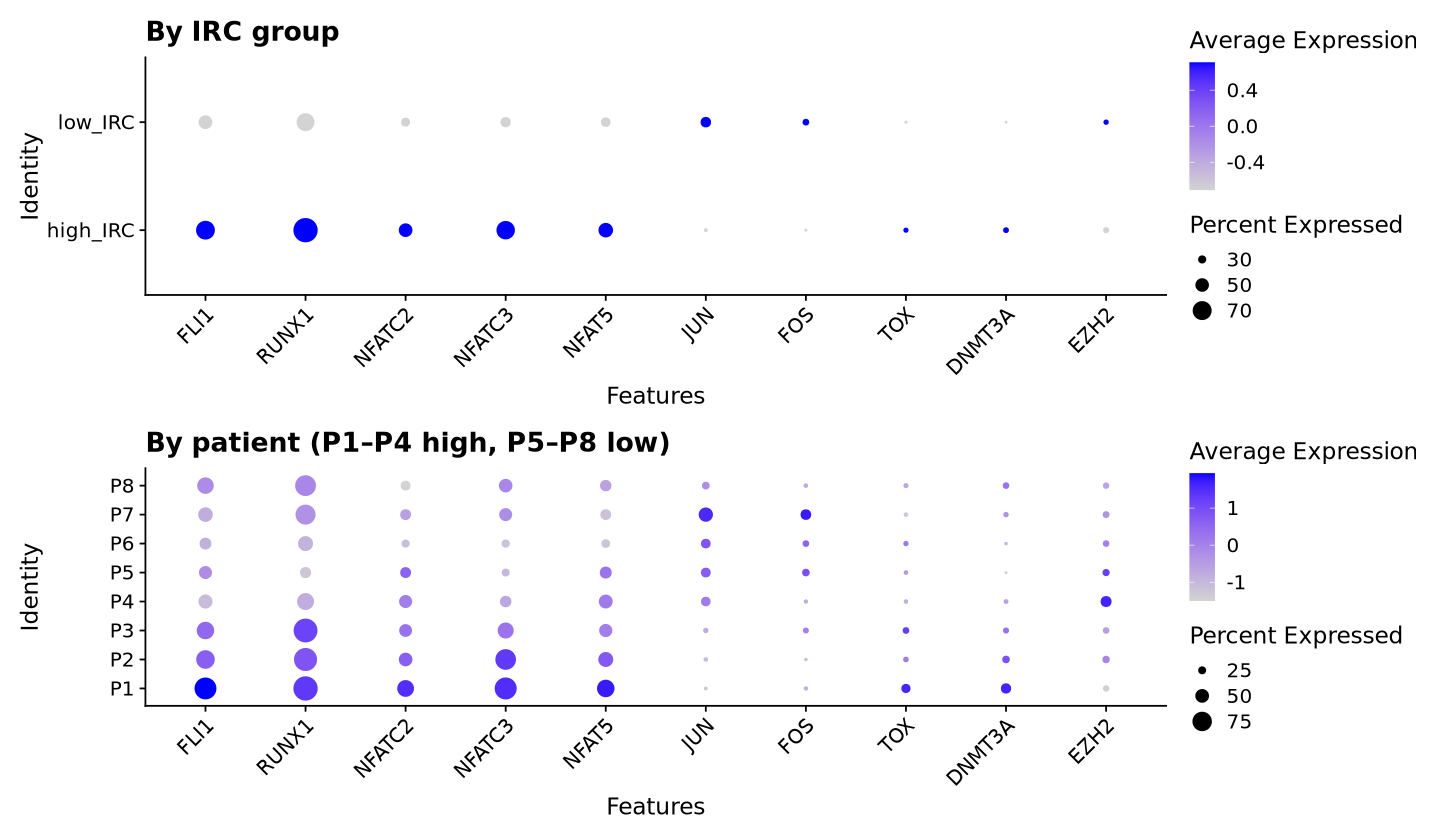

In [8]:
hk_genes <- c("FLI1", "RUNX1", "NFATC2", "NFATC3", "NFAT5", "JUN", "FOS", "TOX", "DNMT3A", "EZH2")
paper_dir <- tibble(gene = hk_genes,
                    paper = c(rep("Higher in high IRC", 5), rep("Higher in low IRC", 2),
                              rep("Higher in high IRC", 3)))

# Cell-level (positive log2FC = higher in high IRC)
hk_cell <- FindMarkers(teff, ident.1 = "high_IRC", ident.2 = "low_IRC", features = hk_genes,
                       logfc.threshold = 0, min.pct = 0, verbose = FALSE) |>
  rownames_to_column("gene") |>
  select(gene, cell_log2FC = avg_log2FC, cell_p = p_val)

# Patient-level
hk_patient <- FetchData(teff, vars = c(hk_genes, "sample", "group")) |>
  pivot_longer(all_of(hk_genes), names_to = "gene", values_to = "expr") |>
  group_by(gene, sample, group) |>
  summarise(mean_expr = mean(expr), .groups = "drop")

hk_pt <- hk_patient |>
  group_by(gene) |>
  summarise(high_mean = mean(mean_expr[group == "high_IRC"]),
            low_mean  = mean(mean_expr[group == "low_IRC"]),
            patient_p = wilcox.test(mean_expr ~ group, exact = TRUE)$p.value,
            .groups = "drop")

fig5hk_check <- paper_dir |>
  left_join(hk_cell, by = "gene") |>
  left_join(hk_pt, by = "gene") |>
  mutate(ours_cell = if_else(cell_log2FC > 0, "Higher in high IRC", "Higher in low IRC"),
         agree_cell = paper == ours_cell & cell_p < 0.05,
         across(where(is.numeric), ~ signif(.x, 3)))
fig5hk_check
write_csv(fig5hk_check, file.path(proj, "results/tables/06_fig5hk_check.csv"))

options(repr.plot.width = 12, repr.plot.height = 7)
p5hk <- (DotPlot(teff, features = hk_genes, group.by = "group") +
           ggtitle("By IRC group") + theme(axis.text.x = element_text(angle = 45, hjust = 1))) /
        (DotPlot(teff, features = hk_genes, group.by = "sample") +
           ggtitle("By patient (P1–P4 high, P5–P8 low)") +
           theme(axis.text.x = element_text(angle = 45, hjust = 1)))
p5hk
ggsave(file.path(proj, "figures/trackB/06_fig5hk_teff.png"), p5hk, width = 12, height = 7, dpi = 150)

### Fig 5h, 5k — NFAT, AP-1, epigenetic genes in Teff
- Cell-level: 9/10 agree with paper. EZH2 not reproduced (P = 0.11, slightly lower in high IRC).
- Patient-level: all 9 in same direction. NFATC2, NFAT5 complete separation (P = 0.029);
  JUN, FOS P = 0.057; RUNX1, NFATC3 P = 0.11; FLI1, TOX, DNMT3A P = 0.20.
- P1 drives much of the high-IRC signal; P4 resembles low-IRC patients for FLI1, RUNX1, NFATC3
  (matches paper's observation that P4 clustered with low IRC in Fig 5c).
- Caveat: JUN/FOS are stress/handling-induced immediate early genes; low-IRC samples also have
  higher mito %. Possible technical contribution -> tested in Step 12.9.

## Step 12.9 — Handling-stress check for the AP-1 (JUN/FOS) signal

sample,group,n_cells,stress,mito
<chr>,<fct>,<int>,<dbl>,<dbl>
P1,high_IRC,587,-0.121,5.79
P2,high_IRC,937,-0.170,6.23
P3,high_IRC,1336,-0.078,5.35
P4,high_IRC,418,-0.010,5.55
P5,low_IRC,327,0.113,11.00
P6,low_IRC,751,0.070,10.11
P7,low_IRC,914,0.129,8.60
P8,low_IRC,420,0.001,8.11


sample,group,rho,p
<chr>,<fct>,<dbl>,<dbl>
P1,high_IRC,0.014,7.28e-01
P2,high_IRC,0.122,1.84e-04
P3,high_IRC,0.083,2.32e-03
P4,high_IRC,0.115,1.90e-02
P5,low_IRC,0.162,3.34e-03
P6,low_IRC,0.182,4.99e-07
P7,low_IRC,0.066,4.66e-02
P8,low_IRC,0.133,6.44e-03


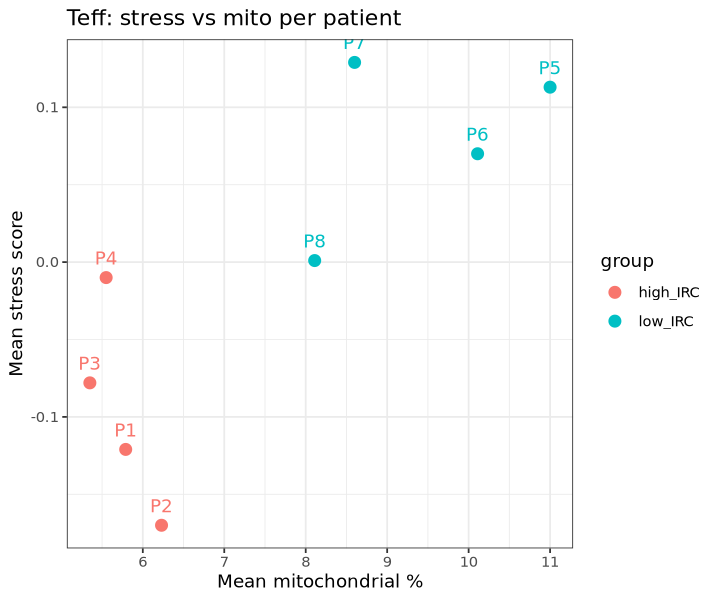

In [9]:
stress_genes <- intersect(c("FOS", "FOSB", "JUN", "JUNB", "JUND", "IER2", "IER3", "EGR1",
                            "DUSP1", "HSPA1A", "HSPA1B", "ATF3", "KLF2", "KLF6", "ZFP36"),
                          rownames(teff))
teff <- AddModuleScore(teff, features = list(stress_genes), name = "stress")

# 1. Per-patient averages
stress_pt <- teff@meta.data |>
  group_by(sample, group) |>
  summarise(n_cells = n(),
            stress  = round(mean(stress1), 3),
            mito    = round(mean(percent.mt), 2),
            .groups = "drop")
stress_pt

# 2. Within-patient: do cells with more mito reads have higher stress scores?
stress_within <- teff@meta.data |>
  group_by(sample, group) |>
  summarise(rho = round(cor(stress1, percent.mt, method = "spearman"), 3),
            p   = signif(cor.test(stress1, percent.mt, method = "spearman", exact = FALSE)$p.value, 3),
            .groups = "drop")
stress_within
write_csv(left_join(stress_pt, stress_within, by = c("sample", "group")),
          file.path(proj, "results/tables/06_stress_check_teff.csv"))

options(repr.plot.width = 6, repr.plot.height = 5)
p_st <- ggplot(stress_pt, aes(mito, stress, colour = group, label = sample)) +
  geom_point(size = 3) + geom_text(vjust = -1, show.legend = FALSE) +
  labs(x = "Mean mitochondrial %", y = "Mean stress score", title = "Teff: stress vs mito per patient") +
  theme_bw()
p_st
ggsave(file.path(proj, "figures/trackB/06_stress_vs_mito_teff.png"), p_st, width = 6, height = 5, dpi = 150)

### Handling-stress check (AP-1 / immediate early genes)
- Stress score (15 IEG/heat-shock genes). Per patient: all 4 low-IRC patients have higher stress
  (0.00–0.13 vs -0.17 to -0.01) AND higher mito (8.1–11.0% vs 5.4–6.2%) -> perfectly confounded
  with IRC group at patient level.
- Within patient: stress vs mito rho positive in 8/8 patients (0.01–0.18), significant in 7/8
  -> weak but consistent technical coupling.
- Implication: higher JUN/FOS (and AP-1 regulons, Fig 5f) in low IRC may partly reflect sample
  handling/quality. Cannot be resolved with these 8 samples.

## Step 12.10 — How much of the stress gap is explained by mito %?

In [10]:
fit <- lm(stress1 ~ percent.mt + sample, data = teff@meta.data)
slope <- unname(coef(fit)["percent.mt"])

hi <- stress_pt$group == "high_IRC"
mito_gap   <- mean(stress_pt$mito[!hi])   - mean(stress_pt$mito[hi])
stress_gap <- mean(stress_pt$stress[!hi]) - mean(stress_pt$stress[hi])

decomp <- tibble(within_patient_slope = signif(slope, 3),
                 slope_p              = signif(summary(fit)$coefficients["percent.mt", 4], 3),
                 mito_gap             = round(mito_gap, 2),
                 observed_stress_gap  = round(stress_gap, 3),
                 expected_from_mito   = round(slope * mito_gap, 3),
                 pct_explained        = round(100 * slope * mito_gap / stress_gap, 1))
decomp
write_csv(decomp, file.path(proj, "results/tables/06_stress_mito_decomposition.csv"))

within_patient_slope,slope_p,mito_gap,observed_stress_gap,expected_from_mito,pct_explained
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.00662,3.86e-16,3.72,0.173,0.025,14.2


## Step 12.11a — Cell-level DE, low vs high IRC Teff (all genes)

In [11]:
ribo <- grepl("^RP[SL]", rownames(teff))

de_cell <- FindMarkers(teff, ident.1 = "low_IRC", ident.2 = "high_IRC",
                       features = rownames(teff)[!ribo],
                       logfc.threshold = 0, min.pct = 0.05, verbose = FALSE) |>
  rownames_to_column("gene")
write_csv(de_cell, file.path(proj, "results/tables/06_de_teff_cell_level.csv"))

cat("Genes tested:", nrow(de_cell), "\n")
cat("Significant (adj P < 0.05, |log2FC| > 0.25):",
    sum(de_cell$p_val_adj < 0.05 & abs(de_cell$avg_log2FC) > 0.25), "\n")

Genes tested: 7780 
Significant (adj P < 0.05, |log2FC| > 0.25): 2465 


## Step 12.11b — Pseudobulk DE (one profile per patient, DESeq2)

In [12]:
suppressPackageStartupMessages(library(DESeq2))

pb <- AggregateExpression(teff, assays = "RNA", group.by = "sample", return.seurat = FALSE)$RNA
pb <- pb[!grepl("^RP[SL]", rownames(pb)), ]
colnames(pb)   # should be P1 ... P8

coldata <- data.frame(sample = colnames(pb)) |>
  mutate(group = factor(if_else(sample %in% c("P1", "P2", "P3", "P4"), "high_IRC", "low_IRC"),
                        levels = c("high_IRC", "low_IRC")))
rownames(coldata) <- coldata$sample

keep <- rowSums(pb >= 10) >= 4          # >= 10 counts in at least 4 patients
dds  <- DESeqDataSetFromMatrix(round(as.matrix(pb[keep, ])), coldata, design = ~ group)
dds  <- DESeq(dds, quiet = TRUE)

de_pb <- results(dds, contrast = c("group", "low_IRC", "high_IRC")) |>
  as.data.frame() |> rownames_to_column("gene") |> arrange(pvalue)
write_csv(de_pb, file.path(proj, "results/tables/06_de_teff_pseudobulk.csv"))

cat("Genes tested:", sum(!is.na(de_pb$padj)), "\n")
cat("Significant (padj < 0.05):", sum(de_pb$padj < 0.05, na.rm = TRUE), "\n")

[1] "P1" "P2" "P3" "P4" "P5" "P6" "P7" "P8"

converting counts to integer mode



Genes tested: 10744 
Significant (padj < 0.05): 328 


## Step 12.11c — Compare the two approaches

In [13]:
cmp <- inner_join(de_cell |> select(gene, cell_lfc = avg_log2FC, cell_padj = p_val_adj),
                  de_pb   |> select(gene, pb_lfc = log2FoldChange, pb_padj = padj),
                  by = "gene")
cat("Spearman correlation of log2FC (cell vs pseudobulk):",
    round(cor(cmp$cell_lfc, cmp$pb_lfc, method = "spearman", use = "complete.obs"), 3), "\n")

key <- c("B2M", "HLA-C", "TXNIP", "MX1", "NFATC2", "NFAT5", "NFATC3", "FLI1", "RUNX1",
         "JUN", "FOS", "TOX", "DNMT3A", "EZH2")
cmp |> filter(gene %in% key) |>
  mutate(across(where(is.numeric), ~ signif(.x, 3))) |>
  arrange(match(gene, key))

Spearman correlation of log2FC (cell vs pseudobulk): 0.981 


gene,cell_lfc,cell_padj,pb_lfc,pb_padj
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
B2M,1.3700,0.00e+00,1.3600,0.000631
HLA-C,1.4900,0.00e+00,1.5500,0.008700
TXNIP,0.6480,1.44e-126,0.8170,0.266000
MX1,0.2360,1.00e+00,0.4800,0.725000
NFATC2,-0.5430,2.95e-25,-0.5110,0.228000
NFAT5,-0.6520,1.90e-34,-0.5610,0.205000
NFATC3,-1.0900,2.41e-113,-1.1000,0.077000
FLI1,-0.6380,3.82e-46,-0.5530,0.301000
RUNX1,-1.2200,3.58e-206,-1.1200,0.060100


### Genome-wide DE, Teff low vs high IRC
- Cell-level Wilcoxon: 2,465 / 7,780 genes significant (32%) -> inflated by pseudoreplication.
- Pseudobulk DESeq2 (4 vs 4): 328 / 10,744 significant (3%).
- log2FC agreement cell vs pseudobulk: Spearman 0.981 -> same pattern, different certainty.
- Robust at patient level: B2M (padj 0.0006), HLA-C (0.009) higher in low IRC; JUN (0.029), FOS (0.035)
  higher in low IRC but stress-confounded.
- Consistent direction, not significant: NFATC2, NFAT5, FLI1, TOX, DNMT3A (padj 0.19–0.30);
  RUNX1, NFATC3 borderline (0.06–0.08). EZH2 and MX1: no difference.

## Step 12.12 — GSEA on the cell-level log2FC ranking

In [14]:
suppressPackageStartupMessages({ library(fgsea); library(msigdbr) })

ranks <- sort(setNames(de_cell$avg_log2FC, de_cell$gene), decreasing = TRUE)

get_sets <- function(...) {
  d <- msigdbr(species = "Homo sapiens", ...)
  split(d$gene_symbol, d$gs_name)
}
sets <- list(
  Hallmark = get_sets(collection = "H"),
  C7       = get_sets(collection = "C7", subcollection = "IMMUNESIGDB"),
  GO_BP    = get_sets(collection = "C5", subcollection = "GO:BP"),
  Reactome = get_sets(collection = "C2", subcollection = "CP:REACTOME"))
sapply(sets, length)

set.seed(42)
gsea_all <- imap_dfr(sets, ~ fgsea(pathways = .x, stats = ranks, minSize = 15,
                                   maxSize = 500, eps = 0) |>
                       as_tibble() |> mutate(collection = .y)) |>
  arrange(padj)

gsea_all |>
  mutate(leadingEdge = map_chr(leadingEdge, paste, collapse = ";")) |>
  write_csv(file.path(proj, "results/tables/06_gsea_teff_all.csv"))

gsea_all |> filter(padj < 0.05) |> count(collection, direction = if_else(NES > 0, "low IRC", "high IRC"))

Hallmark       C7    GO_BP Reactome 
      50     4872     7538     1839

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.03% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.03% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.03% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.03% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


ERROR: Error in count(filter(gsea_all, padj < 0.05), collection, direction = if_else(NES > : Argument 'x' is not a vector: list


In [15]:
gsea_all |> filter(padj < 0.05) |>
  dplyr::count(collection, direction = if_else(NES > 0, "low IRC", "high IRC"))

collection,direction,n
<chr>,<chr>,<int>
C7,high IRC,315
C7,low IRC,299
GO_BP,high IRC,46
GO_BP,low IRC,77
Hallmark,high IRC,2
Hallmark,low IRC,15
Reactome,high IRC,29
Reactome,low IRC,158


## Step 12.13 — The paper's specific gene sets

In [16]:
show <- function(d) d |> dplyr::select(collection, pathway, NES, padj, size) |>
  dplyr::mutate(NES = round(NES, 2), padj = signif(padj, 3))
show <- function(d) d |> select(collection, pathway, NES, padj, size) |>
  mutate(NES = round(NES, 2), padj = signif(padj, 3))

# Fig 5e: PD1 ligation (paper: enriched in low IRC, NES 2.19)
gsea_all |> filter(grepl("GSE24026", pathway)) |> show()

# Fig 5j: chromatin-modifying enzymes (paper: leading-edge genes higher in high IRC)
gsea_all |> filter(grepl("CHROMATIN_MODIFYING", pathway)) |> show()

# Fig 5d proxies: CD4 LCMV sets in ImmuneSigDB
gsea_all |> filter(collection == "C7", grepl("LCMV|CL13|ARMSTRONG", pathway),
                   grepl("CD4", pathway)) |> show()

collection,pathway,NES,padj,size
<chr>,<chr>,<dbl>,<dbl>,<int>
C7,GSE24026_PD1_LIGATION_VS_CTRL_IN_ACT_TCELL_LINE_UP,2.46,7.64e-09,119
C7,GSE24026_PD1_LIGATION_VS_CTRL_IN_ACT_TCELL_LINE_DN,-1.35,1.47e-01,128


collection,pathway,NES,padj,size
<chr>,<chr>,<dbl>,<dbl>,<int>


collection,pathway,NES,padj,size
<chr>,<chr>,<dbl>,<dbl>,<int>
C7,GSE43863_NAIVE_VS_LY6C_LOW_CXCR5NEG_CD4_EFF_TCELL_D6_LCMV_DN,1.61,0.0456,85
C7,GSE10094_LCMV_VS_LISTERIA_IND_EFF_CD4_TCELL_UP,-1.39,0.1330,145
C7,GSE10094_LCMV_VS_LISTERIA_IND_EFF_CD4_TCELL_DN,1.45,0.1910,45
C7,GSE43863_NAIVE_VS_MEMORY_TFH_CD4_TCELL_D150_LCMV_UP,-1.23,0.2690,114
C7,GSE43863_NAIVE_VS_MEMORY_LY6C_INT_CXCR5POS_CD4_TCELL_D150_LCMV_UP,-1.23,0.2850,111
C7,GSE43863_NAIVE_VS_MEMORY_LY6C_INT_CXCR5POS_CD4_TCELL_D150_LCMV_DN,1.22,0.3100,125
C7,GSE43863_NAIVE_VS_TFH_CD4_EFF_TCELL_D6_LCMV_DN,1.25,0.3270,44
C7,GSE43863_NAIVE_VS_LY6C_INT_CXCR5POS_CD4_EFF_TCELL_D6_LCMV_DN,-1.20,0.3970,40
C7,GSE43863_NAIVE_VS_LY6C_LOW_CXCR5NEG_CD4_EFF_TCELL_D6_LCMV_UP,1.16,0.4690,49


### GSEA — paper's specific gene sets (ranked by cell-level log2FC, low vs high IRC)
- Fig 5e PD1 ligation (GSE24026_..._UP): NES 2.46, FDR 7.6e-9 -> enriched in low IRC.
  Reproduced (paper NES 2.19, FDR 0.018). _DN set NES -1.35 (ns), consistent direction.
- Fig 5j chromatin-modifying enzymes: not found under expected name -> checked in Step 12.15.
- Fig 5d: paper's custom LCMV CD4 sets (memory, Tfh, dysfunctional Cl13) not in MSigDB.
  Closest proxies (GSE43863, acute LCMV): Tfh vs naive genes NES +1.25 (low IRC, ns);
  Th1-like effector genes NES 1.61, FDR 0.046 (low IRC). No chronic/dysfunctional CD4 set available.
  -> Fig 5d not reproducible with public gene sets; proxies do not support Tfh enrichment in high IRC.

## Step 12.14 — Top enriched sets per collection and direction

In [17]:
gsea_all |>
  filter(padj < 0.05) |>
  mutate(direction = if_else(NES > 0, "low IRC", "high IRC")) |>
  group_by(collection, direction) |>
  slice_max(abs(NES), n = 5) |>
  ungroup() |>
  dplyr::select(collection, direction, pathway, NES, padj) |>
  mutate(NES = round(NES, 2), padj = signif(padj, 3))

collection,direction,pathway,NES,padj
<chr>,<chr>,<chr>,<dbl>,<dbl>
C7,high IRC,GSE21063_3H_VS_16H_ANTI_IGM_STIM_BCELL_DN,-2.41,1.97e-09
C7,high IRC,GSE16450_CTRL_VS_IFNA_12H_STIM_IMMATURE_NEURON_CELL_LINE_UP,-2.36,7.20e-11
C7,high IRC,GSE10240_IL17_VS_IL17_AND_IL22_STIM_PRIMARY_BRONCHIAL_EPITHELIAL_CELLS_DN,-2.17,3.99e-05
C7,high IRC,GSE19825_NAIVE_VS_IL2RAHIGH_DAY3_EFF_CD8_TCELL_UP,-2.13,3.13e-04
C7,high IRC,GSE25088_CTRL_VS_IL4_STIM_MACROPHAGE_UP,-2.11,4.01e-05
C7,low IRC,GSE26030_TH1_VS_TH17_RESTIMULATED_DAY5_POST_POLARIZATION_UP,2.68,4.27e-11
C7,low IRC,GSE45837_WT_VS_GFI1_KO_PDC_DN,2.61,2.19e-11
C7,low IRC,GSE2405_0H_VS_9H_A_PHAGOCYTOPHILUM_STIM_NEUTROPHIL_DN,2.55,4.73e-10
C7,low IRC,GSE42088_UNINF_VS_LEISHMANIA_INF_DC_2H_DN,2.52,4.76e-09


### GSEA top themes (Fig 5i)
- High IRC: small GTPase / Rac1 / RhoB signalling, cell junction & adhesion, O-linked glycosylation,
  JNK, mitotic spindle -> matches paper (Rac/Rho, Ras, adhesion, motility).
- Low IRC: oxidative phosphorylation, electron transport, ATP synthesis, Complex I/IV (NES 2.4–3.0),
  TNFA via NFKB, MYC targets, ROS -> matches paper (OXPHOS, respiration, mitochondria, translation).
- Concern: OXPHOS genes are abundant cytoplasmic mRNAs (likely co-vary with MT- reads in nuclei data);
  TNFA/NFKB set is rich in stress/IEG genes; B2M/HLA-C also highly abundant.
  Low-IRC samples have higher mito % -> technical alternative explanation. Test by mito-adjusted GSEA.

## Step 12.15 — Find and test the chromatin-modifying enzymes set

In [19]:
# 1. Test the closest available Reactome sets
cm <- c("REACTOME_CHROMATIN_ORGANIZATION", "REACTOME_ATP_DEPENDENT_CHROMATIN_REMODELERS")
tibble(pathway    = cm,
       set_size   = map_int(sets$Reactome[cm], ~ length(unique(.x))),
       in_ranking = map_int(sets$Reactome[cm], ~ sum(unique(.x) %in% names(ranks))))

set.seed(42)
cme <- fgsea(pathways = sets$Reactome[cm], stats = ranks, minSize = 15, maxSize = 2000, eps = 0)
cme |> as_tibble() |> mutate(collection = "Reactome") |> show()

# 2. The 23 genes shown in the paper's Fig 5j heatmap (paper: higher in high IRC)
paper_5j <- c("SETD3", "EP300", "SUZ12", "DNMT3A", "KDM3B", "ARID1A", "KDM3A", "KAT6A",
              "KANSL1", "KDM7A", "SMYD3", "KDM6A", "SETD2", "CREBBP", "KDM4C", "NCOR1",
              "ARID2", "HDAC8", "NCOA2", "KAT6B", "JAK2", "KAT2B", "ARID5B")

fig5j_check <- tibble(gene = paper_5j) |>
  left_join(de_cell |> dplyr::select(gene, cell_lfc = avg_log2FC, cell_padj = p_val_adj), by = "gene") |>
  left_join(de_pb   |> dplyr::select(gene, pb_lfc = log2FoldChange, pb_padj = padj), by = "gene") |>
  mutate(higher_in_high_IRC = cell_lfc < 0,
         across(where(is.numeric), ~ signif(.x, 3)))
fig5j_check
write_csv(fig5j_check, file.path(proj, "results/tables/06_fig5j_check.csv"))

cat("Higher in high IRC (cell-level):", sum(fig5j_check$higher_in_high_IRC, na.rm = TRUE),
    "of", sum(!is.na(fig5j_check$cell_lfc)), "genes tested\n")
cat("Significant in pseudobulk (padj < 0.05):", sum(fig5j_check$pb_padj < 0.05, na.rm = TRUE), "\n")

pathway,set_size,in_ranking
<chr>,<int>,<int>
REACTOME_CHROMATIN_ORGANIZATION,287,174
REACTOME_ATP_DEPENDENT_CHROMATIN_REMODELERS,31,24


Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.03% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


collection,pathway,NES,padj,size
<chr>,<chr>,<dbl>,<dbl>,<int>
Reactome,REACTOME_ATP_DEPENDENT_CHROMATIN_REMODELERS,-0.69,0.904,24
Reactome,REACTOME_CHROMATIN_ORGANIZATION,-1.14,0.312,174


gene,cell_lfc,cell_padj,pb_lfc,pb_padj,higher_in_high_IRC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
SETD3,-0.8400,4.44e-15,-0.8640,0.0522,TRUE
EP300,-0.0754,1.00e+00,-0.0681,0.9010,TRUE
SUZ12,-0.1620,2.88e-01,-0.2300,0.6450,TRUE
DNMT3A,-0.9810,4.72e-20,-0.9470,0.1930,TRUE
KDM3B,-0.2900,1.97e-06,-0.3790,0.3690,TRUE
ARID1A,-0.2410,1.76e-05,-0.2580,0.5010,TRUE
KDM3A,-0.4760,9.29e-12,-0.4860,0.1570,TRUE
KAT6A,-0.1060,2.62e-01,-0.1480,0.8060,TRUE
KANSL1,-0.0442,1.00e+00,-0.1960,0.7500,TRUE


Higher in high IRC (cell-level): 23 of 23 genes tested
Significant in pseudobulk (padj < 0.05): 0 


### Fig 5j — chromatin-modifying enzymes
- REACTOME_CHROMATIN_MODIFYING_ENZYMES not in this MSigDB release (Reactome reorganisation).
  Closest: CHROMATIN_ORGANIZATION NES -1.14 (towards high IRC), FDR 0.31 (ns);
  ATP_DEPENDENT_CHROMATIN_REMODELERS NES -0.69, ns.
- Paper's 23 leading-edge genes: 23/23 higher in high IRC cell-level (19 significant);
  pseudobulk same direction for all 23, none significant (SETD3 padj 0.052).
- Caveat: these genes were selected as leading edge in the same data -> confirms pipeline,
  not independent evidence. Pathway-wide enrichment not supported.

## Step 12.16 — Mito-adjusted patient-level differences and GSEA

In [20]:
genes_use <- de_cell$gene
Y  <- as.matrix(t(LayerData(teff, layer = "data")[genes_use, ]))   # cells x genes
mt <- teff$percent.mt
pt <- teff$sample
n_pt <- as.vector(table(pt)[pt])

# 1. Within-patient slope of each gene on mito %
Yd    <- Y - rowsum(Y, pt)[pt, ] / n_pt
mtd   <- mt - ave(mt, pt)
slope <- setNames(as.vector(crossprod(Yd, mtd)) / sum(mtd^2), genes_use)
rm(Yd); invisible(gc())

# 2. Remove the mito-related component
Yadj <- Y - outer(mt - mean(mt), slope)

# 3. Patient means, then low minus high IRC
pmean <- function(M) rowsum(M, pt) / as.vector(table(pt))
low   <- sort(unique(pt)) %in% c("P5", "P6", "P7", "P8")
pm_raw <- pmean(Y);    diff_raw <- colMeans(pm_raw[low, ]) - colMeans(pm_raw[!low, ])
pm_adj <- pmean(Yadj); diff_adj <- colMeans(pm_adj[low, ]) - colMeans(pm_adj[!low, ])
rm(Y, Yadj); invisible(gc())

cat("Correlation of raw vs adjusted differences:", round(cor(diff_raw, diff_adj), 3), "\n")

# 4. GSEA on key pathways, before vs after adjustment
key_sets <- c("HALLMARK_OXIDATIVE_PHOSPHORYLATION", "GOBP_OXIDATIVE_PHOSPHORYLATION",
              "REACTOME_RESPIRATORY_ELECTRON_TRANSPORT", "HALLMARK_MYC_TARGETS_V1",
              "HALLMARK_TNFA_SIGNALING_VIA_NFKB", "HALLMARK_INTERFERON_ALPHA_RESPONSE",
              "GSE24026_PD1_LIGATION_VS_CTRL_IN_ACT_TCELL_LINE_UP",
              "GOBP_SMALL_GTPASE_MEDIATED_SIGNAL_TRANSDUCTION", "REACTOME_RAC1_GTPASE_CYCLE",
              "GOBP_CELL_CELL_JUNCTION_ORGANIZATION", "REACTOME_CHROMATIN_ORGANIZATION")
key_list <- c(sets$Hallmark, sets$GO_BP, sets$Reactome, sets$C7)[key_sets]

run_key <- function(stat) {
  set.seed(42)
  fgsea(key_list, sort(stat, decreasing = TRUE), minSize = 15, maxSize = 2000, eps = 0) |>
    as_tibble() |> dplyr::select(pathway, NES, pval)
}
mito_gsea <- full_join(run_key(diff_raw), run_key(diff_adj), by = "pathway",
                       suffix = c("_raw", "_adj")) |>
  mutate(NES_change_pct = round(100 * (NES_adj - NES_raw) / abs(NES_raw), 1),
         across(c(NES_raw, NES_adj), ~ round(.x, 2)),
         across(c(pval_raw, pval_adj), ~ signif(.x, 3))) |>
  arrange(match(pathway, key_sets))
mito_gsea
write_csv(mito_gsea, file.path(proj, "results/tables/06_mito_adjusted_gsea_key.csv"))

# 5. Key genes before vs after
tibble(gene = c("B2M", "HLA-C", "JUN", "FOS", "NFATC2", "NFAT5", "RUNX1", "KAT2B", "NDUFA4", "COX7C"),
       diff_raw = round(diff_raw[gene], 3), diff_adj = round(diff_adj[gene], 3),
       mito_slope = signif(slope[gene], 3))

Correlation of raw vs adjusted differences: 0.951 


Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.03% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“There were 2 pathways for which P-values were not calculated properly due to unbalanced (positive and negative) gene-level statistic values. For such pathways pval, padj, NES, log2err are set to NA. You can try to increase the value of the argument nPermSimple (for example set it nPermSimple = 10000)”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.03% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


pathway,NES_raw,pval_raw,NES_adj,pval_adj,NES_change_pct
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HALLMARK_OXIDATIVE_PHOSPHORYLATION,NA,NA,2.13,2.06e-09,NA
GOBP_OXIDATIVE_PHOSPHORYLATION,3.01,1.63e-21,1.83,1.12e-04,-39.1
REACTOME_RESPIRATORY_ELECTRON_TRANSPORT,2.50,4.77e-15,1.76,2.87e-04,-29.5
HALLMARK_MYC_TARGETS_V1,NA,NA,1.76,4.67e-05,NA
HALLMARK_TNFA_SIGNALING_VIA_NFKB,2.19,1.63e-08,2.15,4.30e-07,-2.1
HALLMARK_INTERFERON_ALPHA_RESPONSE,1.74,1.53e-03,1.91,5.14e-04,10.1
GSE24026_PD1_LIGATION_VS_CTRL_IN_ACT_TCELL_LINE_UP,2.16,4.42e-09,2.20,9.63e-09,1.8
GOBP_SMALL_GTPASE_MEDIATED_SIGNAL_TRANSDUCTION,-1.66,5.42e-11,-1.80,1.38e-11,-8.8
REACTOME_RAC1_GTPASE_CYCLE,-1.61,2.13e-05,-1.79,6.77e-07,-11.1


gene,diff_raw,diff_adj,mito_slope
<chr>,<dbl>,<dbl>,<dbl>
B2M,0.960,0.868,0.02470
HLA-C,1.038,0.924,0.03060
JUN,0.382,0.346,0.00952
FOS,0.209,0.190,0.00507
NFATC2,-0.244,-0.200,-0.01200
NFAT5,-0.307,-0.283,-0.00647
RUNX1,-0.796,-0.671,-0.03330
KAT2B,-0.562,-0.543,-0.00492
NDUFA4,0.205,0.219,-0.00362


### Mito-adjusted analysis (within-patient mito slope removed; patient-weighted differences)
- Raw vs adjusted gene differences: r = 0.951 (modest correction).
- OXPHOS attenuated: GO:BP 3.01 -> 1.83 (-39%), Reactome resp. ETC 2.50 -> 1.76 (-30%); still significant
  -> partly mito-linked, partly not explained by mito.
- Unaffected: TNFA/NFKB (-2%), PD1 ligation (+2%), IFN-alpha (+10%).
- High-IRC themes robust/stronger: small GTPase, Rac1, cell junctions, chromatin organisation.
- B2M, HLA-C, JUN, FOS attenuated ~10% only.
- Correction to Step 12.15: chromatin organisation significant with patient-weighted ranking
  (NES -1.67, P = 6e-9) but not with Seurat cell-pooled ranking (NES -1.14, FDR 0.31)
  -> result depends on ranking metric.
- Limitation: removes only cell-level mito-linked variation; sample-wide handling effects not removable.

## Step 12.17 — Cytokines, chemokines and cell-cycle genes in Teff (Ext Data Fig 7f)

Cytokines Chemokines    S_phase  G2M_phase 
        38         25         43         53

Genes tested: 159  | adj P < 0.05: 0 


gene,high_mean,low_mean,p,padj,category
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
CCL5,0.13300,0.263000,0.0286,0.467,Chemokines
CENPE,0.03920,0.025500,0.0286,0.467,G2M_phase
CKAP5,0.27000,0.173000,0.0286,0.467,G2M_phase
HMGB2,0.20500,0.357000,0.0286,0.467,G2M_phase
IL18,0.00525,0.019300,0.0286,0.467,Cytokines
IL26,0.00571,0.015800,0.0286,0.467,Cytokines
NUSAP1,0.02450,0.017800,0.0286,0.467,G2M_phase
POLA1,0.23700,0.136000,0.0286,0.467,S_phase
POLR1B,0.08260,0.071900,0.0286,0.467,S_phase


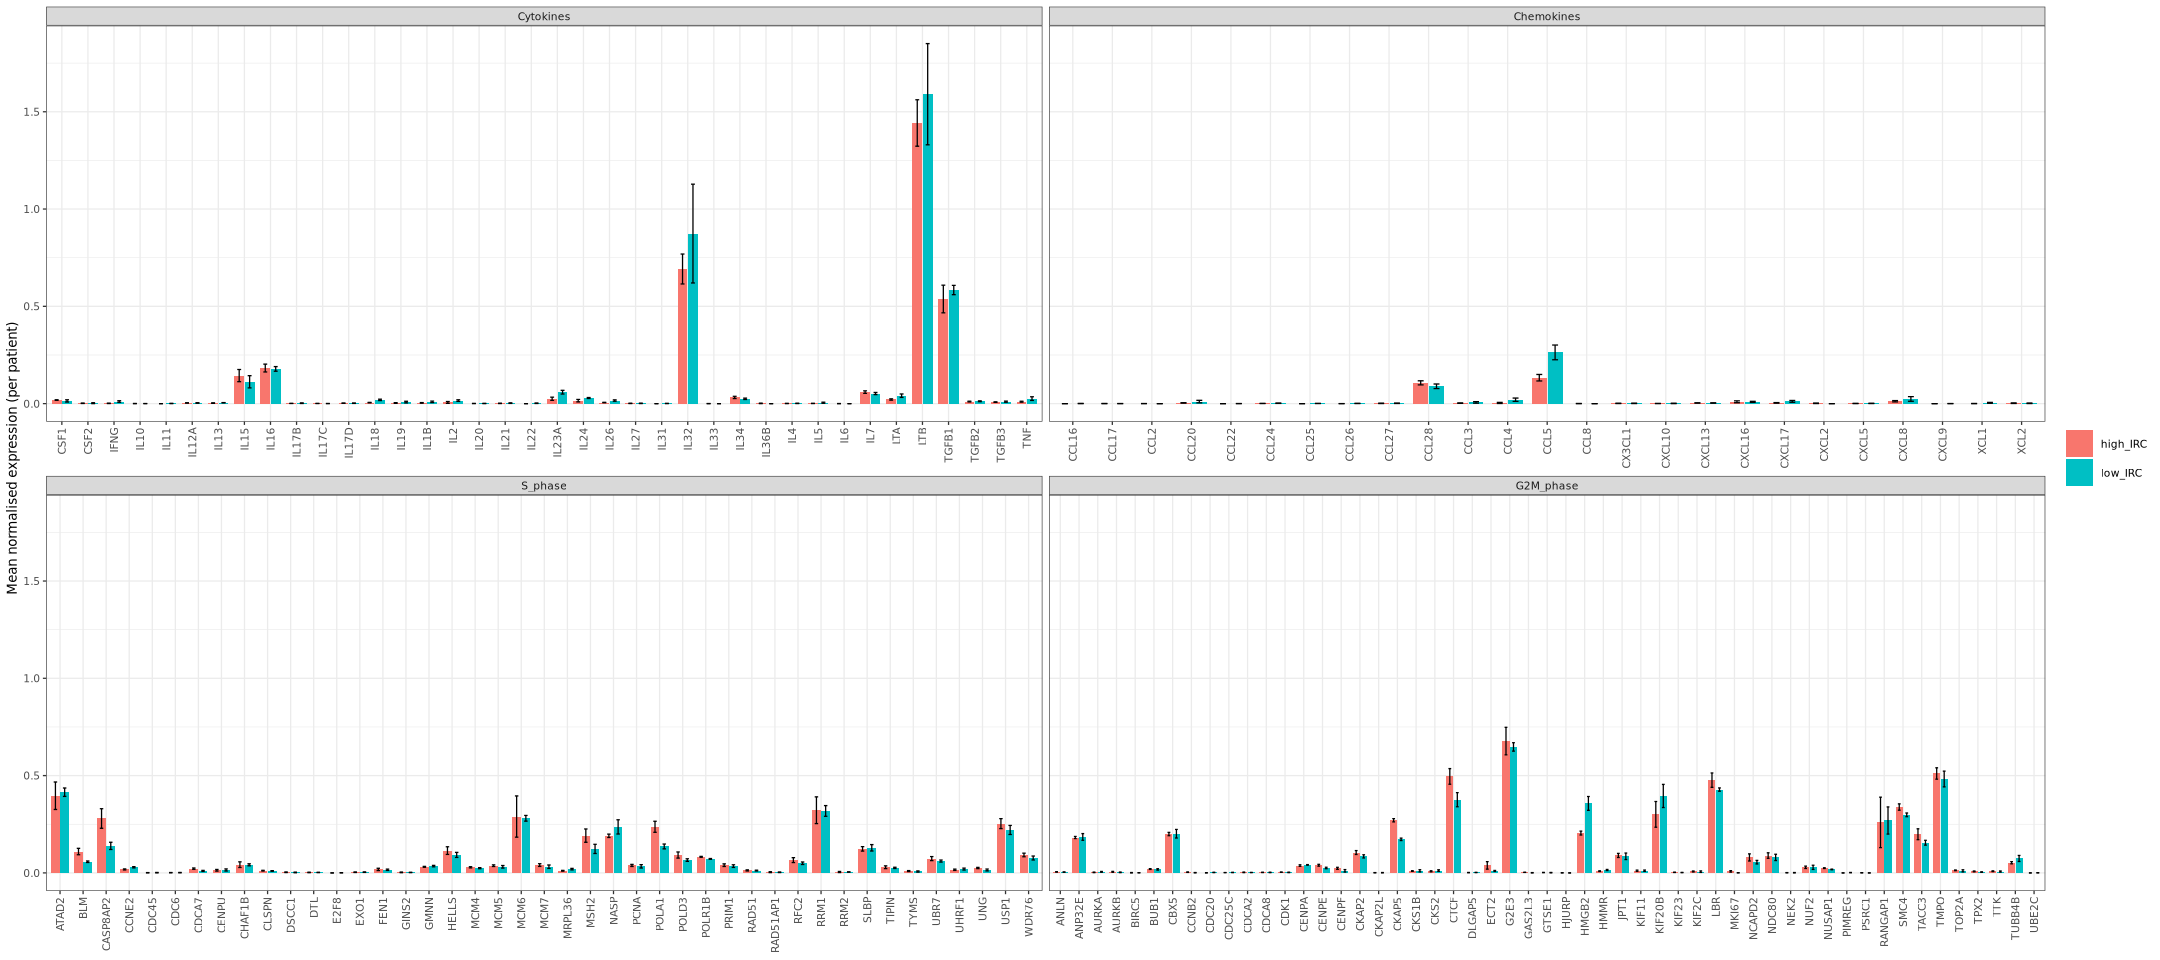

In [21]:
det_genes <- rownames(teff)[Matrix::rowSums(LayerData(teff, layer = "counts") > 0) > 0]
cc <- Seurat::cc.genes.updated.2019

gene_groups <- list(
  Cytokines  = grep("^(IL[0-9]+[A-QS-Z]?|IFNG|TNF|LTA|LTB|CSF[0-9]|TGFB[0-9])$", det_genes, value = TRUE),
  Chemokines = grep("^(CCL|CXCL|XCL|CX3CL)[0-9]+$", det_genes, value = TRUE),
  S_phase    = intersect(cc$s.genes, det_genes),
  G2M_phase  = intersect(cc$g2m.genes, det_genes))
sapply(gene_groups, length)

cat_map   <- stack(gene_groups) |> dplyr::rename(gene = values, category = ind)
ed7f_genes <- unique(cat_map$gene)

pm7f <- FetchData(teff, vars = c(ed7f_genes, "sample", "group")) |>
  pivot_longer(all_of(ed7f_genes), names_to = "gene", values_to = "expr") |>
  group_by(gene, sample, group) |>
  summarise(mean_expr = mean(expr), .groups = "drop")

ed7f <- pm7f |>
  group_by(gene) |>
  summarise(high_mean = mean(mean_expr[group == "high_IRC"]),
            low_mean  = mean(mean_expr[group == "low_IRC"]),
            p = suppressWarnings(wilcox.test(mean_expr ~ group, exact = TRUE)$p.value),
            .groups = "drop") |>
  mutate(padj = p.adjust(p, method = "BH")) |>
  left_join(cat_map, by = "gene") |>
  arrange(p)

cat("Genes tested:", nrow(ed7f), " | adj P < 0.05:", sum(ed7f$padj < 0.05, na.rm = TRUE), "\n")
ed7f |> slice_head(n = 10) |> mutate(across(where(is.numeric), ~ signif(.x, 3)))
write_csv(ed7f, file.path(proj, "results/tables/06_extfig7f_teff.csv"))

# Plot: mean ± SE across patients, by category
p7f_df <- pm7f |> left_join(cat_map, by = "gene") |>
  group_by(category, gene, group) |>
  summarise(m = mean(mean_expr), se = sd(mean_expr) / sqrt(n()), .groups = "drop")

options(repr.plot.width = 18, repr.plot.height = 8)
p7f <- ggplot(p7f_df, aes(x = gene, y = m, fill = group)) +
  geom_col(position = position_dodge(0.8), width = 0.75) +
  geom_errorbar(aes(ymin = m - se, ymax = m + se), position = position_dodge(0.8), width = 0.3) +
  facet_wrap(~ category, scales = "free_x", nrow = 2) +
  labs(x = NULL, y = "Mean normalised expression (per patient)", fill = NULL) +
  theme_bw(base_size = 8) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))
p7f
ggsave(file.path(proj, "figures/trackB/06_extfig7f_teff.png"), p7f, width = 18, height = 8, dpi = 150)

### Ext Data Fig 7f — cytokines, chemokines, cell cycle (CD4 Teff, patient-level)
- 159 detected genes (38 cytokines, 25 chemokines, 43 S-phase, 53 G2/M); Wilcoxon on patient means, BH.
- 0 genes with adj P < 0.05 -> reproduces paper. Most genes near zero -> quiescent Teff in both groups.
- 9 genes at minimum P = 0.029 (complete separation); ~4.5 expected by chance among 159.
- Suggestive: CCL5 and HMGB2 higher in low IRC (HMGB2 regulon enriched in low IRC in paper Fig 5f).

## Step 12.18 — Load CD8 effector memory cells from patients

In [22]:
rm(cd4, teff, pm7f); invisible(gc())

obj <- readRDS(file.path(proj, "results/objects/04_annotated_rpca.rds"))
cd8 <- subset(obj, subset = celltype == "CD8 effector memory" & group %in% c("high_IRC", "low_IRC"))
rm(obj); invisible(gc())

cnt <- LayerData(cd8, layer = "counts")
cd4_only <- cnt["CD4", ] > 0 & cnt["CD8A", ] == 0 & cnt["CD8B", ] == 0
cat("Removing", sum(cd4_only), "CD4-only cells of", ncol(cd8), "\n")
cd8 <- subset(cd8, cells = colnames(cd8)[!cd4_only])
rm(cnt); invisible(gc())

cd8$group <- factor(cd8$group, levels = c("high_IRC", "low_IRC"))
Idents(cd8) <- "group"
table(cd8$sample, cd8$group)

Removing 198 CD4-only cells of 6818 


    
     high_IRC low_IRC
  P1     1298       0
  P2     1271       0
  P3      572       0
  P4      161       0
  P5        0     423
  P6        0    1147
  P7        0    1108
  P8        0     640

## Step 12.19 — CD8 exhaustion score (Ext Data Fig 7g)

sample,group,n_cells,score
<chr>,<fct>,<int>,<dbl>
P1,high_IRC,1298,0.0425
P2,high_IRC,1271,0.0076
P3,high_IRC,572,0.0662
P4,high_IRC,161,0.0205
P5,low_IRC,423,-0.0090
P6,low_IRC,1147,-0.0281
P7,low_IRC,1108,0.0240
P8,low_IRC,640,-0.0033


Cell-level P: 1.19e-18  | Patient-level P: 0.114 


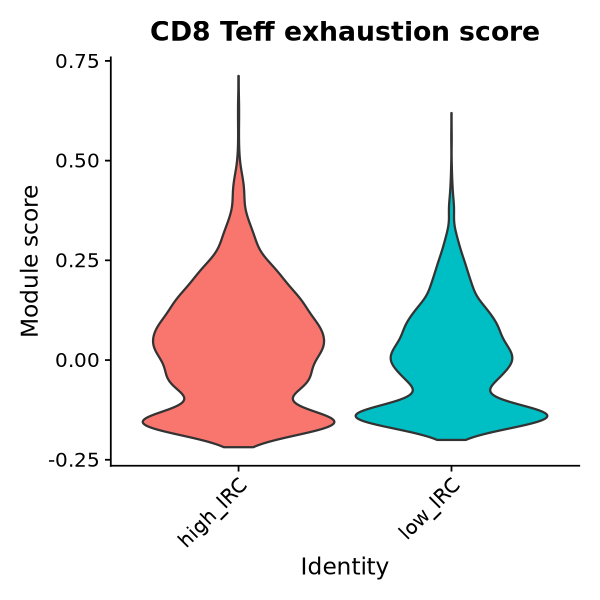

In [23]:
exh_genes <- intersect(c("PDCD1", "HAVCR2", "LAG3", "TIGIT", "CTLA4", "TOX", "TOX2",
                         "ENTPD1", "CD244", "CD160", "CXCL13", "LAYN"), rownames(cd8))
cd8 <- AddModuleScore(cd8, features = list(exh_genes), name = "exhaustion")

p_cell <- wilcox.test(exhaustion1 ~ group, data = cd8@meta.data)$p.value

exh_pt <- cd8@meta.data |>
  group_by(sample, group) |>
  summarise(n_cells = n(), score = round(mean(exhaustion1), 4), .groups = "drop")
p_patient <- wilcox.test(score ~ group, data = exh_pt, exact = TRUE)$p.value

exh_pt
cat("Cell-level P:", signif(p_cell, 3), " | Patient-level P:", signif(p_patient, 3), "\n")
write_csv(exh_pt, file.path(proj, "results/tables/06_extfig7g_cd8_exhaustion_per_patient.csv"))

options(repr.plot.width = 5, repr.plot.height = 5)
p7g <- VlnPlot(cd8, features = "exhaustion1", group.by = "group", pt.size = 0) +
  labs(title = "CD8 Teff exhaustion score", y = "Module score") + NoLegend()
p7g
ggsave(file.path(proj, "figures/trackB/06_extfig7g_cd8_exhaustion.png"), p7g, width = 5, height = 5, dpi = 150)

### Ext Data Fig 7g — CD8 Teff exhaustion score
- CD8 effector memory, patients only; removed 198 CD4-only cells (2.9%) -> 6,620 cells
  (high 3,302; low 3,318). Undetected CD4 contamination likely remains. P4 only 161 cells.
- Proxy signature (PDCD1, HAVCR2, LAG3, TIGIT, CTLA4, TOX, TOX2, ENTPD1, CD244, CD160, CXCL13, LAYN);
  paper used Bengsch et al. signature (list not given).
- Cell-level: higher in high IRC, P = 1.2e-18 (paper P = 3.9e-114) -> direction reproduced.
- Patient-level: high mean ~0.034 vs low ~-0.004; P7 (low) overlaps high group; P = 0.114 (ns).
- Bimodal distribution: lower peak = cells with no exhaustion genes detected (snRNA sparsity).

## Step 12.20 — PD1 ligation and exhaustion gene sets in CD8 Teff (Ext Data Fig 7h)

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.04% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


pathway,NES,padj,size
<chr>,<dbl>,<dbl>,<int>
GSE24026_PD1_LIGATION_VS_CTRL_IN_ACT_TCELL_LINE_DN,-1.07,3.82e-01,134
GSE24026_PD1_LIGATION_VS_CTRL_IN_ACT_TCELL_LINE_UP,2.28,5.60e-09,122
GSE9650_EXHAUSTED_VS_MEMORY_CD8_TCELL_DN,1.01,4.26e-01,155
GSE9650_EXHAUSTED_VS_MEMORY_CD8_TCELL_UP,1.27,1.77e-01,75


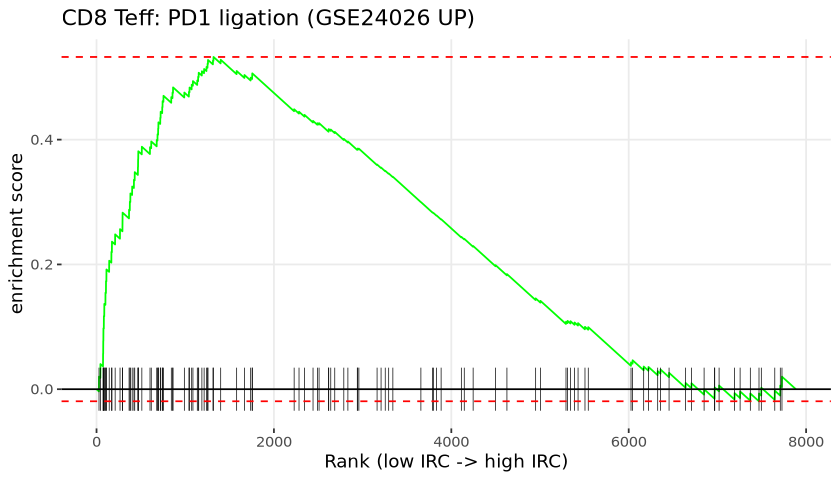

In [24]:
de_cd8 <- FindMarkers(cd8, ident.1 = "low_IRC", ident.2 = "high_IRC",
                      features = rownames(cd8)[!grepl("^RP[SL]", rownames(cd8))],
                      logfc.threshold = 0, min.pct = 0.05, verbose = FALSE) |>
  rownames_to_column("gene")
write_csv(de_cd8, file.path(proj, "results/tables/06_de_cd8_cell_level.csv"))

ranks8 <- sort(setNames(de_cd8$avg_log2FC, de_cd8$gene), decreasing = TRUE)
cd8_sets <- sets$C7[grep("GSE24026_PD1_LIGATION|GSE9650_EXHAUSTED_VS_MEMORY", names(sets$C7), value = TRUE)]

set.seed(42)
gsea_cd8 <- fgsea(cd8_sets, ranks8, minSize = 15, maxSize = 2000, eps = 0, nPermSimple = 10000) |>
  as_tibble() |>
  dplyr::select(pathway, NES, padj, size) |>
  mutate(NES = round(NES, 2), padj = signif(padj, 3))
gsea_cd8

options(repr.plot.width = 7, repr.plot.height = 4)
p7h <- plotEnrichment(sets$C7[["GSE24026_PD1_LIGATION_VS_CTRL_IN_ACT_TCELL_LINE_UP"]], ranks8) +
  labs(title = "CD8 Teff: PD1 ligation (GSE24026 UP)", x = "Rank (low IRC -> high IRC)")
p7h
ggsave(file.path(proj, "figures/trackB/06_extfig7h_cd8_pd1_ligation.png"), p7h, width = 7, height = 4, dpi = 150)

### Ext Data Fig 7h — PD1 ligation and exhaustion sets in CD8 Teff
- GSE24026 PD1 ligation UP: NES 2.28, FDR 5.6e-9 -> enriched in low IRC (paper NES 2.02, FDR 0.039).
  Reproduced; same as CD4 (NES 2.46). DN set NES -1.07 (ns), consistent.
- GSE9650 exhausted-vs-memory CD8 UP: NES +1.27 (towards low IRC, ns) -> does NOT support higher
  exhaustion in high IRC. Exhaustion result signature-dependent (canonical markers: high IRC, cell-level only).